# 01 — AMI Dataset Exploration

**Project:** MeetingMind  |  **Phase:** 2 (Dataset and ML experimentation)

## Goal
Understand the AMI Meeting Corpus *annotations* well enough to decide how to build a training set for a
**decision / action-item utterance detector**.

## What this notebook does
1. Downloads the AMI manual annotations (text only, no audio)
2. Inspects the folder structure and raw XML (we do NOT assume file formats)
3. Parses words and dialogue acts into a flat utterance table
4. Computes basic statistics
5. Prints a findings summary that you paste back to me

## What this notebook does NOT do
No labels for "decision/action" are created here. Those depend on how the abstractive-summary annotation
links to dialogue acts. That linking structure is what cell 8 lets us inspect. Label construction is notebook 02.

## 1. Imports

In [1]:
import re
import zipfile
import collections
import xml.etree.ElementTree as ET
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Configuration
Paths are resolved relative to the project root so the notebook works whether you launch Jupyter from the
root or from `notebooks/`.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ami"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATION_URLS = [
    "https://groups.inf.ed.ac.uk/ami/AMICorpusAnnotations/ami_public_manual_1.6.2.zip",
    "http://groups.inf.ed.ac.uk/ami/AMICorpusAnnotations/ami_public_manual_1.6.2.zip",
]
ZIP_PATH = RAW_DIR / "ami_public_manual_1.6.2.zip"

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)

Project root: c:\Users\Harijith\Downloads
Raw data dir: c:\Users\Harijith\Downloads\data\raw\ami


## 3. Download and unzip
Source: official AMI corpus site (University of Edinburgh). The annotations are released under CC BY 4.0
(see https://groups.inf.ed.ac.uk/ami/download/). Cite the AMI corpus paper (Carletta et al., 2005) in the README later.

In [3]:
def download_file(urls: list[str], destination: Path) -> None:
    """Stream-download the first working URL to `destination`. Skips if file exists."""
    if destination.exists() and destination.stat().st_size > 0:
        print(f"Already downloaded: {destination.name} ({destination.stat().st_size / 1e6:.1f} MB)")
        return
    last_error = None
    for url in urls:
        try:
            with requests.get(url, stream=True, timeout=60) as response:
                response.raise_for_status()
                total = int(response.headers.get("content-length", 0))
                with open(destination, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=destination.name) as bar:
                    for chunk in response.iter_content(chunk_size=1 << 16):
                        f.write(chunk)
                        bar.update(len(chunk))
            print("Downloaded from:", url)
            return
        except Exception as e:  # noqa: BLE001 - we want to try the next URL
            last_error = e
            print(f"Failed: {url} -> {e}")
            if destination.exists():
                destination.unlink()
    raise RuntimeError(f"All download URLs failed. Last error: {last_error}")


download_file(ANNOTATION_URLS, ZIP_PATH)

if not any(p.is_dir() and p.name == "words" for p in RAW_DIR.rglob("words")):
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(RAW_DIR)
    print("Extracted.")
else:
    print("Already extracted.")

# The zip may extract into a subfolder; locate the folder that contains 'words/'
ANN_ROOT = next(p.parent for p in RAW_DIR.rglob("words") if p.is_dir())
print("Annotation root:", ANN_ROOT)

ami_public_manual_1.6.2.zip:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Downloaded from: https://groups.inf.ed.ac.uk/ami/AMICorpusAnnotations/ami_public_manual_1.6.2.zip
Extracted.
Annotation root: c:\Users\Harijith\Downloads\data\raw\ami


## 4. Folder structure
Each sub-folder is one annotation layer (words, dialogue acts, summaries, ...). We list them with file counts
and example filenames instead of assuming what exists.

In [4]:
for folder in sorted(p for p in ANN_ROOT.iterdir() if p.is_dir()):
    files = sorted(f for f in folder.rglob("*") if f.is_file())
    print(f"{folder.name:<25} {len(files):>5} files   e.g. {[f.name for f in files[:3]]}")

print("\nTop-level files:", [f.name for f in ANN_ROOT.iterdir() if f.is_file()])

abstractive                 142 files   e.g. ['ES2002a.abssumm.xml', 'ES2002b.abssumm.xml', 'ES2002c.abssumm.xml']
argumentation               565 files   e.g. ['ES2002a.A.argumentstructs.xml', 'ES2002a.B.argumentstructs.xml', 'ES2002a.C.argumentstructs.xml']
configuration                 2 files   e.g. ['amiConfig.xml', 'amiSubConfig.xml']
corpusdoc                    73 files   e.g. ['annot_abssumm.html', 'annot_abstract.html', 'annot_actions.html']
corpusResources               2 files   e.g. ['meetings.xml', 'participants.xml']
decision                     47 files   e.g. ['ES2002a.decision.xml', 'ES2002d.decision.xml', 'ES2006a.decision.xml']
dialogueActs                695 files   e.g. ['ES2002a.A.dialog-act.xml', 'ES2002a.adjacency-pairs.xml', 'ES2002a.B.dialog-act.xml']
disfluency                  160 files   e.g. ['ES2002a.A.disfluency.xml', 'ES2002a.B.disfluency.xml', 'ES2002a.C.disfluency.xml']
extractive                  274 files   e.g. ['ES2002a.extsumm.xml', 'ES2002a.sum

## 5. Meetings and speakers
AMI naming: `ES2002a` = Edinburgh scenario meeting, session 2002, meeting *a* (of a-d).
Prefixes: ES/IS/TS = scenario meetings recorded at Edinburgh/Idiap/TNO; IB/EN = non-scenario meetings.
Speakers in a meeting are seat letters A, B, C, D.

In [5]:
WORDS_RE = re.compile(r"^(?P<meeting>[A-Za-z]{2}\d{4}[a-z]?)\.(?P<speaker>[A-Z])\.words\.xml$")

meeting_speakers = collections.defaultdict(list)
for path in sorted((ANN_ROOT / "words").glob("*.words.xml")):
    m = WORDS_RE.match(path.name)
    if m:
        meeting_speakers[m["meeting"]].append(m["speaker"])

meeting_ids = sorted(meeting_speakers)
print("Meetings with word-level transcripts:", len(meeting_ids))
print("Prefix counts:", collections.Counter(mid[:2] for mid in meeting_ids))
print("First 10:", meeting_ids[:10])

Meetings with word-level transcripts: 171
Prefix counts: Counter({'ES': 60, 'TS': 40, 'IS': 38, 'EN': 16, 'IN': 10, 'IB': 7})
First 10: ['EN2001a', 'EN2001b', 'EN2001d', 'EN2001e', 'EN2002a', 'EN2002b', 'EN2002c', 'EN2002d', 'EN2003a', 'EN2004a']


## 6. Raw XML peek: words
Look at the raw file first. This is the same habit you need for any unfamiliar dataset.

In [6]:
def peek(path: Path, n_chars: int = 700) -> None:
    """Print the first n_chars of a text file."""
    text = Path(path).read_text(encoding="utf-8", errors="replace")
    print(f"--- {Path(path).relative_to(ANN_ROOT)}  ({len(text):,} chars) ---")
    print(text[:n_chars])
    print()

SAMPLE_MEETING = "ES2002a" if "ES2002a" in meeting_ids else meeting_ids[0]
print("Sample meeting:", SAMPLE_MEETING)
peek(ANN_ROOT / "words" / f"{SAMPLE_MEETING}.A.words.xml")

Sample meeting: ES2002a
--- words\ES2002a.A.words.xml  (25,103 chars) ---
<?xml version="1.0" encoding="ISO-8859-1" standalone="yes"?>
<nite:root nite:id="ES2002a.A.words" xmlns:nite="http://nite.sourceforge.net/">
   <w nite:id="ES2002a.A.words0" starttime="77.44" endtime="77.74">Hi</w>
   <w nite:id="ES2002a.A.words1" starttime="77.74" endtime="77.74" punc="true">,</w>
   <w nite:id="ES2002a.A.words2" starttime="77.74" endtime="78.16">I&#39;m</w>
   <w nite:id="ES2002a.A.words3" starttime="78.16" endtime="78.6">David</w>
   <w nite:id="ES2002a.A.words4" starttime="78.6" endtime="78.85">and</w>
   <w nite:id="ES2002a.A.words5" starttime="78.85" endtime="79.16">I&#39;m</w>
   <w nite:id="ES2002a.A.words6" starttime="79.16" endtime="79.53">supposed</w>
   <w nite:i



## 7. Parsers
NXT (the XML format) uses a namespace and `href` pointers like `file.xml#id(a)..id(b)` to refer to a range of
words. Dialogue acts therefore do not contain text; they *point* to word ranges.

Two functions:
- `parse_words`: ordered list of word/token elements with timing
- `parse_dialogue_acts`: list of dialogue acts, each with word-id ranges and pointers (e.g. to the act type)

In [7]:
HREF_RE = re.compile(r"#id\(([^)]+)\)(?:\.\.id\(([^)]+)\))?")


def local(tag: str) -> str:
    """Strip the XML namespace: '{ns}dact' -> 'dact'."""
    return tag.split("}")[-1]


def attrs(element: ET.Element) -> dict[str, str]:
    """Attributes with namespaces stripped: '{ns}id' -> 'id'."""
    return {local(k): v for k, v in element.attrib.items()}


def parse_words(path: Path) -> list[dict]:
    """Return every id-bearing element of a words file in document order.

    Tags include 'w' (word), plus non-word events (vocalsound, disfmarker, gap, ...).
    Only 'w' elements contribute text later.
    """
    root = ET.parse(path).getroot()
    items = []
    for el in root.iter():
        if el is root:
            continue
        a = attrs(el)
        if "id" not in a:
            continue
        items.append({
            "id": a["id"],
            "tag": local(el.tag),
            "start": float(a["starttime"]) if "starttime" in a else None,
            "end": float(a["endtime"]) if "endtime" in a else None,
            "text": (el.text or "").strip(),
            "is_punc": a.get("punc") == "true",
        })
    return items


def parse_dialogue_acts(path: Path) -> list[dict]:
    """Return dialogue acts as dicts: id, word ranges [(first_id, last_id)], pointers [(role, target_id)]."""
    root = ET.parse(path).getroot()
    acts = []
    for el in root.iter():
        if local(el.tag) != "dact":
            continue
        ranges, pointers = [], []
        for child in el:
            kind = local(child.tag)
            a = attrs(child)
            href = a.get("href")
            if not href:
                continue
            m = HREF_RE.search(href)
            if not m:
                continue
            first, last = m.group(1), m.group(2) or m.group(1)
            if kind == "child":
                ranges.append((first, last))
            elif kind == "pointer":
                pointers.append((a.get("role", ""), first))
        acts.append({"id": attrs(el).get("id"), "ranges": ranges, "pointers": pointers})
    return acts


def join_tokens(tokens: list[str]) -> str:
    """Join tokens with spaces and remove the space before punctuation."""
    return re.sub(r"\s+([.,?!;:])", r"\1", " ".join(tokens)).strip()

## 8. Raw XML peek: every other annotation folder
This is the important cell for the next notebook. Look at:
- `dialogueActs/` — how acts point to words and to their type
- `abstractive/` — summary sentences, and whether they carry a *type* (abstract / decisions / actions / problems)
- anything that links abstractive sentences to dialogue acts

If a folder has many files, we only peek at one for the sample meeting.

In [8]:
for folder in sorted(p for p in ANN_ROOT.iterdir() if p.is_dir() and p.name != "words"):
    candidates = sorted(folder.glob(f"{SAMPLE_MEETING}*")) or sorted(folder.glob("*"))
    candidates = [c for c in candidates if c.is_file()]
    if not candidates:
        print(f"[{folder.name}] no files\n")
        continue
    print(f"##### {folder.name}: {len(candidates)} matching file(s) for sample meeting")
    for f in candidates[:2]:
        peek(f, n_chars=900)

##### abstractive: 1 matching file(s) for sample meeting
--- abstractive\ES2002a.abssumm.xml  (1,691 chars) ---
<?xml version="1.0" encoding="ISO-8859-1" standalone="yes"?>
<nite:root xmlns:nite="http://nite.sourceforge.net/">
<abstract nite:id="ES2002a.rdhillon.abstract.1">

<sentence nite:id="ES2002a.rdhillon.s.1">The project manager introduced the upcoming project to the team members and then the team members participated in an exercise in which they drew their favorite animal and discussed what they liked about the animal.</sentence>  <sentence nite:id="ES2002a.rdhillon.s.2">The project manager talked about the project finances and selling prices.</sentence>  <sentence nite:id="ES2002a.rdhillon.s.3">The team then discussed various features to consider in making the remote.</sentence> 
</abstract>
<actions nite:id="ES2002a.rdhillon.actions.1">

<sentence nite:id="ES2002a.rdhillon.s.4">The industrial designer will work on the working design of the remote.</sentence>
<sentence nite:id

## 9. Dialogue act type ontology
Dialogue acts point to a type id (for example `ami_da_3`). The ontology file maps ids to human-readable names.
We print its raw content first, then build an id -> name dictionary defensively.

In [9]:
ontology_files = list(ANN_ROOT.rglob("da-types.xml"))
print("Ontology files found:", [str(p.relative_to(ANN_ROOT)) for p in ontology_files])
if ontology_files:
    peek(ontology_files[0], n_chars=1500)

Ontology files found: ['ontologies\\da-types.xml']
--- ontologies\da-types.xml  (1,625 chars) ---
<?xml version="1.0" encoding="ISO-8859-1" standalone="yes"?>
<da-type nite:id="cmrda" name="da-type" xmlns:nite="http://nite.sourceforge.net/" xmlns:xlink="http://www.w3.org/1999/xlink">
   <da-type nite:id="ami_daclass_0" name="minor" gloss="Minor">
      <da-type nite:id="ami_da_1" name="bck" gloss="Backchannel"/>
      <da-type nite:id="ami_da_2" name="stl" gloss="Stall"/>
      <da-type nite:id="ami_da_3" name="fra" gloss="Fragment"/>
   </da-type>
   <da-type nite:id="ami_daclass_1" name="task" gloss="Task">
      <da-type nite:id="ami_da_4" name="inf" gloss="Inform"/>
      <da-type nite:id="ami_da_6" name="sug" gloss="Suggest"/>
      <da-type nite:id="ami_da_9" name="ass" gloss="Assess"/>
   </da-type>
   <da-type nite:id="ami_daclass_2" name="elicit" gloss="Elicit">
      <da-type nite:id="ami_da_5" name="el.inf" gloss="Elicit-Inform"/>
      <da-type nite:id="ami_da_8" name="el.s

In [10]:
def load_da_type_names(ontology_path: Path) -> dict[str, str]:
    """Map every element id in the ontology to a readable name (gloss > name > id)."""
    root = ET.parse(ontology_path).getroot()
    mapping = {}
    for el in root.iter():
        a = attrs(el)
        if "id" in a:
            mapping[a["id"]] = a.get("gloss") or a.get("name") or a["id"]
    return mapping


da_names = load_da_type_names(ontology_files[0]) if ontology_files else {}
print(f"{len(da_names)} ontology entries")
for k, v in list(da_names.items())[:25]:
    print(f"  {k:<15} -> {v}")

21 ontology entries
  cmrda           -> da-type
  ami_daclass_0   -> Minor
  ami_da_1        -> Backchannel
  ami_da_2        -> Stall
  ami_da_3        -> Fragment
  ami_daclass_1   -> Task
  ami_da_4        -> Inform
  ami_da_6        -> Suggest
  ami_da_9        -> Assess
  ami_daclass_2   -> Elicit
  ami_da_5        -> Elicit-Inform
  ami_da_8        -> Elicit-Offer-Or-Suggestion
  ami_da_11       -> Elicit-Assessment
  ami_da_13       -> Elicit-Comment-Understanding
  ami_daclass_3   -> Other
  ami_da_7        -> Offer
  ami_da_12       -> Comment-About-Understanding
  ami_da_14       -> Be-Positive
  ami_da_15       -> Be-Negative
  ami_da_16       -> Other
  ami_daclass_4   -> Unlab


## 10. Build an utterance table
One row per dialogue act, in our future transcript schema (speaker / start / end / text) plus the AMI act type.
This is intentionally close to the structure MeetingMind's speech pipeline will output later.

First for one meeting, so you can inspect it. Then for all meetings.

In [11]:
def build_meeting_utterances(meeting_id: str, ann_root: Path, da_type_names: dict[str, str]) -> list[dict]:
    """Turn one meeting's words + dialogue acts into utterance rows."""
    rows = []
    for speaker in meeting_speakers[meeting_id]:
        words_path = ann_root / "words" / f"{meeting_id}.{speaker}.words.xml"
        da_path = ann_root / "dialogueActs" / f"{meeting_id}.{speaker}.dialog-act.xml"
        if not da_path.exists():
            continue

        items = parse_words(words_path)
        position = {item["id"]: i for i, item in enumerate(items)}

        for act in parse_dialogue_acts(da_path):
            tokens, starts, ends = [], [], []
            for first, last in act["ranges"]:
                if first not in position or last not in position:
                    continue
                for item in items[position[first]: position[last] + 1]:
                    if item["tag"] == "w" and item["text"]:
                        tokens.append(item["text"])
                    if item["start"] is not None:
                        starts.append(item["start"])
                    if item["end"] is not None:
                        ends.append(item["end"])
            if not tokens:
                continue

            # Prefer the pointer whose role mentions 'da-aspect'; otherwise the first pointer.
            type_id = next((t for role, t in act["pointers"] if "da-aspect" in role), None)
            if type_id is None and act["pointers"]:
                type_id = act["pointers"][0][1]

            rows.append({
                "meeting_id": meeting_id,
                "speaker": f"{meeting_id}_{speaker}",
                "dact_id": act["id"],
                "start": min(starts) if starts else None,
                "end": max(ends) if ends else None,
                "text": join_tokens(tokens),
                "da_type_id": type_id,
                "da_type": da_type_names.get(type_id, type_id),
            })
    rows.sort(key=lambda r: (r["start"] is None, r["start"]))
    return rows


sample_df = pd.DataFrame(build_meeting_utterances(SAMPLE_MEETING, ANN_ROOT, da_names))
print(sample_df.shape)
sample_df.head(25)

(434, 8)


,meeting_id,speaker,dact_id,start,end,text,da_type_id,da_type
0,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.1,50.420,50.99,Okay,ami_da_2,Stall
1,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.2,53.560,53.96,Right,ami_da_2,Stall
2,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.3,55.415,60.35,Um well this is the kick-off meeting for our o...,ami_da_4,Inform
3,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.16,60.350,64.16,Um and um,ami_da_2,Stall
4,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.17,64.160,67.55,this is just what we're gonna be doing over th...,ami_da_4,Inform
5,ES2002a,ES2002a_D,ES2002a.D.dialog-act.dharshi.1,67.210,67.45,Mm-hmm.,ami_da_1,Backchannel
6,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.6,67.550,72.79,"Um so first of all, just to kind of make sure ...",ami_da_4,Inform
7,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.9,72.790,74.42,I'm Laura and I'm the project manager.,ami_da_4,Inform
8,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.7,74.420,77.29,Do you want to introduce yourself again?,ami_da_5,Elicit-Inform
9,ES2002a,ES2002a_D,ES2002a.D.dialog-act.dharshi.2,74.890,75.24,Great.,ami_da_1,Backchannel


In [12]:
all_rows = []
for meeting_id in tqdm(meeting_ids, desc="Meetings"):
    try:
        all_rows.extend(build_meeting_utterances(meeting_id, ANN_ROOT, da_names))
    except ET.ParseError as e:
        print(f"Parse error in {meeting_id}: {e}")

utterances = pd.DataFrame(all_rows)
utterances["n_words"] = utterances["text"].str.split().str.len()

out_path = PROCESSED_DIR / "ami_utterances_raw.csv"
utterances.to_csv(out_path, index=False)
print("Saved:", out_path, utterances.shape)

Meetings:   0%|          | 0/171 [00:00<?, ?it/s]

Saved: c:\Users\Harijith\Downloads\data\processed\ami_utterances_raw.csv (110795, 9)


## 11. Statistics
What to look for:
- **Meetings with dialogue acts**: how many meetings can we actually use?
- **Act-type distribution**: expect heavy imbalance (backchannels and fragments dominate). This matters
  for choosing metrics later (accuracy would be misleading).
- **Utterance length**: many utterances are 1-3 words ("yeah", "mm-hmm"). Short fragments carry no decision or action
  content and will need handling in preprocessing.

In [13]:
print("Meetings with >=1 utterance:", utterances["meeting_id"].nunique(), "of", len(meeting_ids))
print("Total utterances:", len(utterances))
print("Speakers:", utterances["speaker"].nunique())
print("Rows with missing timestamps:", utterances["start"].isna().sum())
print("Rows with missing act type:", utterances["da_type_id"].isna().sum())
print()
print(utterances["n_words"].describe().round(2))

Meetings with >=1 utterance: 139 of 171
Total utterances: 110795
Speakers: 556
Rows with missing timestamps: 0
Rows with missing act type: 26

count    110795.00
mean          6.16
std           6.31
min           1.00
25%           1.00
50%           4.00
75%           9.00
max          77.00
Name: n_words, dtype: float64


da_type
Inform                          33475
Assess                          21388
Backchannel                     12554
Fragment                         9725
Suggest                          9391
Stall                            8447
Elicit-Inform                    4240
Comment-About-Understanding      2366
Elicit-Assessment                2265
Be-Positive                      2209
Other                            2202
Offer                            1530
Elicit-Offer-Or-Suggestion        686
Elicit-Comment-Understanding      193
Be-Negative                        98
Name: count, dtype: int64


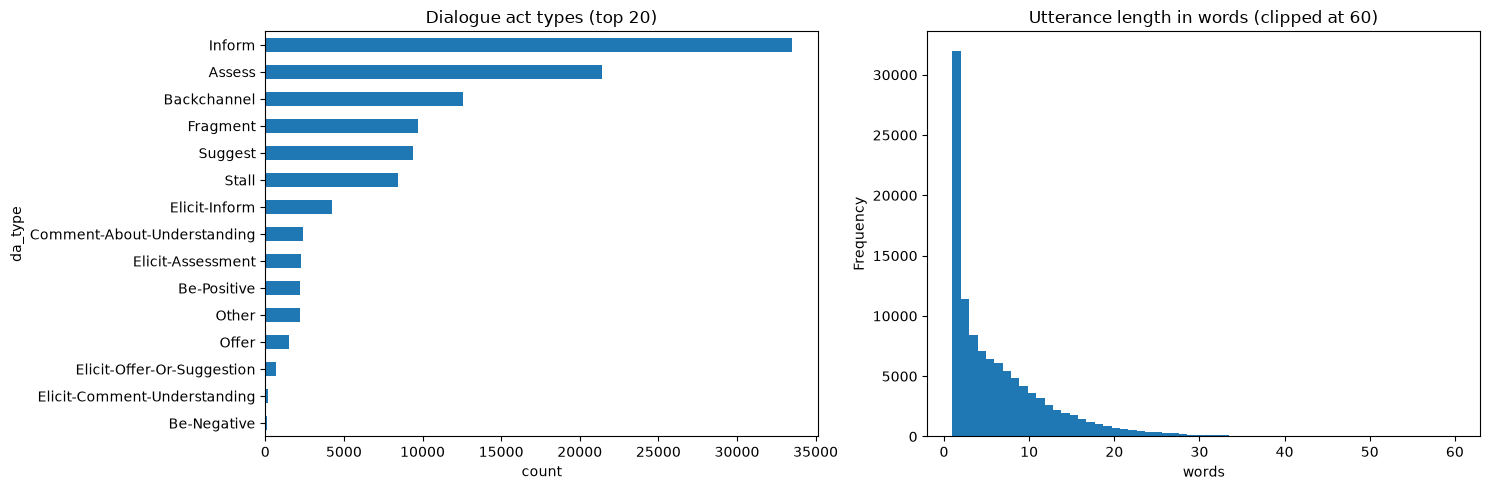

In [14]:
type_counts = utterances["da_type"].value_counts()
print(type_counts.head(25))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
type_counts.head(20).sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Dialogue act types (top 20)")
axes[0].set_xlabel("count")

utterances["n_words"].clip(upper=60).plot.hist(bins=60, ax=axes[1])
axes[1].set_title("Utterance length in words (clipped at 60)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

In [15]:
meetings_per_type = utterances.groupby("meeting_id").size()
print("Utterances per meeting:")
print(meetings_per_type.describe().round(1))

print("\nRandom utterances longer than 8 words:")
utterances[utterances["n_words"] > 8].sample(10, random_state=42)[["meeting_id", "speaker", "start", "da_type", "text"]]

Utterances per meeting:
count     139.0
mean      797.1
std       351.2
min       140.0
25%       543.5
50%       777.0
75%       974.5
max      2179.0
dtype: float64

Random utterances longer than 8 words:


,meeting_id,speaker,start,da_type,text
14064,ES2006c,ES2006c_A,93.030,Inform,"Okay, so uh I'll start again with a brief intr..."
19995,ES2008c,ES2008c_C,813.470,Inform,there's no point having a television that you ...
72322,TS3003c,TS3003c_C,1893.580,Inform,The the single curved so I'm not really sure w...
43597,ES2016c,ES2016c_B,1420.190,Inform,Hence we might not be able to put it in there.
38897,ES2015b,ES2015b_B,125.500,Inform,"I, I only, uh, received my emails later on. 'C..."
31197,ES2012b,ES2012b_A,1897.220,Inform,and says oh I should have put the phone on to ...
47359,IS1000c,IS1000c_C,1162.320,Inform,like if you have an L_C_D_ display and all tho...
52355,IS1002c,IS1002c_B,566.400,Suggest,Well then why don't you just press the up button?
41646,ES2015d,ES2015d_D,1211.720,Assess,"So, I think we did as as much as you can with ..."
107534,TS3012b,TS3012b_C,2011.984,Elicit-Inform,Did they really said it like that? Those two t...


## 12. Findings summary
Run this cell and paste the output back to me. It tells me the exact structure I need for notebook 02.

In [16]:
print("=== FINDINGS TO REPORT ===")
print("ANN_ROOT contents:", sorted(p.name for p in ANN_ROOT.iterdir()))
print("Meetings:", len(meeting_ids), "| with utterances:", utterances["meeting_id"].nunique())
print("Utterances:", len(utterances))
print("Distinct act types:", utterances["da_type"].nunique())
print("Top 5 act types:", type_counts.head(5).to_dict())
print("Median words per utterance:", utterances["n_words"].median())
print("Ontology entries:", len(da_names))
print()
print("ALSO PASTE: the output of section 8 (raw XML of the abstractive/ and any linking folders).")

=== FINDINGS TO REPORT ===
ANN_ROOT contents: ['00README_MANUAL.txt', 'AMI-metadata.xml', 'LICENCE.txt', 'MANIFEST_MANUAL.txt', 'abstractive', 'ami_public_manual_1.6.2.zip', 'argumentation', 'configuration', 'corpusResources', 'corpusdoc', 'decision', 'dialogueActs', 'disfluency', 'extractive', 'focus', 'handGesture', 'headGesture', 'manifest_1.7.html', 'movement', 'namedEntities', 'ontologies', 'participantRoles', 'participantSummaries', 'resource.xml', 'segments', 'topics', 'words', 'youUsages']
Meetings: 171 | with utterances: 139
Utterances: 110795
Distinct act types: 15
Top 5 act types: {'Inform': 33475, 'Assess': 21388, 'Backchannel': 12554, 'Fragment': 9725, 'Suggest': 9391}
Median words per utterance: 4.0
Ontology entries: 21

ALSO PASTE: the output of section 8 (raw XML of the abstractive/ and any linking folders).
